<a href="https://colab.research.google.com/github/yandri918/belajar_machine_learning_buku_ONNO-W-Purba/blob/1April2026/Evaluasi_klasifikasi_terpadu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ( confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_curve, roc_auc_score )

In [2]:
print("=" * 80)
print("BAB 22 - EVALUASI MODEL KLASIFIKASI")
print("=" * 80)

BAB 22 - EVALUASI MODEL KLASIFIKASI


In [3]:
# 1. Load data
df = pd.read_csv("evaluasi_klasifikasi_mahasiswa.csv")

In [4]:
print("\n[1] DATA AWAL")
print(df.head())


[1] DATA AWAL
   jam_belajar  kehadiran  tugas  lulus
0            2         70     60      0
1            3         72     62      0
2            4         75     65      0
3            5         78     68      0
4            6         80     72      1


In [5]:
print("\nDistribusi kelas:")
print(df["lulus"].value_counts())


Distribusi kelas:
lulus
1    12
0     6
Name: count, dtype: int64


In [6]:
# 2. Fitur dan target
X = df[["jam_belajar", "kehadiran", "tugas"]]
y = df["lulus"]

In [7]:
# 3. Split data
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.25, random_state=42, stratify=y )

In [8]:
# 4. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# 5. Model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [10]:
# 6. Prediksi
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [11]:
# 7. Metrik dasar
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

In [12]:
print("\n[2] CONFUSION MATRIX")
print(cm)


[2] CONFUSION MATRIX
[[2 0]
 [0 3]]


In [13]:
print("\n[3] METRIK DASAR")
print("Accuracy :", acc)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)
print("ROC-AUC  :", auc)


[3] METRIK DASAR
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0
ROC-AUC  : 1.0


In [14]:
print("\n[4] CLASSIFICATION REPORT")
print(classification_report(y_test, y_pred))


[4] CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         3

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



In [15]:
# 8. ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

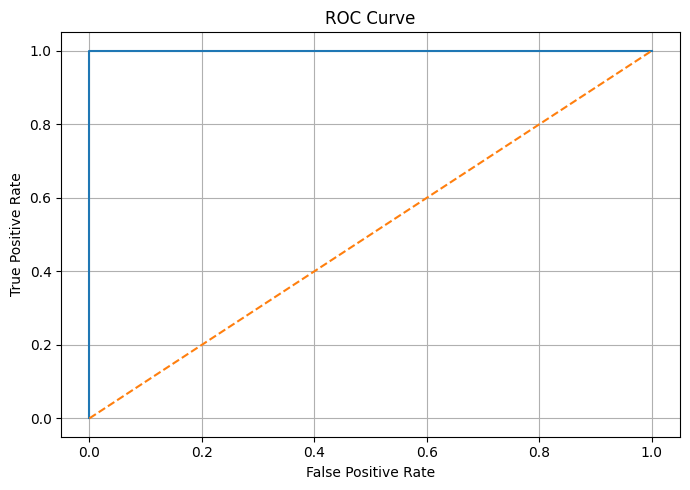

In [16]:
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
print("\nSELESAI. Anda sudah mengevaluasi model klasifikasi secara lebih lengkap.")
print("=" * 80)


SELESAI. Anda sudah mengevaluasi model klasifikasi secara lebih lengkap.
